#### Using python notebook for data exploration and cleaner pandas visualization

- Organize data into DataFrames
- Clean data
- Analyze the data
- Download the new cleaned, merged dataset

In [231]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# show all columns
pd.set_option("display.max_columns", None)


In [232]:
file_path = "data/Case_Study_Data.xlsx"

df1 = pd.read_excel(file_path, sheet_name="Medical claims data")
df2 = pd.read_excel(file_path, sheet_name="member_data_with_surveys")

# Cleans Member ID issue early on
df1["Member ID_num"] = pd.to_numeric(df1["Member ID"], errors="coerce")
bad_ids = df1[df1["Member ID_num"].notna() & (df1["Member ID_num"] % 1 != 0)]
good_ids = df1[df1["Member ID_num"].notna() & (df1["Member ID_num"] % 1 == 0)].copy()
good_ids["Member ID_clean"] = good_ids["Member ID_num"].astype("Int64")

# Cleans amount paid issue early
df1["Paid Amount"] = (df1["Paid Amount"].replace("-", pd.NA).pipe(pd.to_numeric, errors="coerce"))

# Confirm the columns exist
print(df1.columns.tolist())
print(df2.columns.tolist())

# Confirm sample raw values
print("df1 raw:", df1["Member ID"].head(10).tolist())
print("df2 raw:", df2["Member ID"].head(10).tolist())

['Member ID', 'Claim Number', 'Service Date', 'Paid Date', 'Place of Service Description', 'Speciality', 'Provider Specialty', 'Paid Amount', 'Allowed Amount', 'Primary Diagnosis Desc', 'Procedure Description', 'CPT4', 'Vendor Name', 'Procedure', 'Procedure Grouper Desc', 'Procedure Sub-Grouper Desc', 'Diagnosis Grouper 1 Desc', 'Diagnosis Super-Grouper 1 Desc', 'Member ID_num']
['Member ID', 'Age', 'Member Gender', 'Prospective Risk', 'Concurrent Risk', '# of Chronic Conditions', 'ADHD', 'Asthma', 'Blood Disorders', 'Cancer', 'Chronic Pain', 'Congestive Heart Failure', 'Chronic Respiratory Failure', 'Depression', 'Diabetes', 'ESRD', 'Eating Disorders', 'HIV/AIDS', 'Hyperlipidemia', 'Hypertension', 'Lower Back Pain', 'Patient Survey Response']
df1 raw: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
df2 raw: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


Validation of dataframes 1 & 2

In [233]:
summary1 = pd.DataFrame({
    "dtype": df1.dtypes,
    "missing_count": df1.isna().sum(),
    "n_unique": df1.nunique()
})

summary2 = pd.DataFrame({
    "dtype": df2.dtypes,
    "missing_count": df2.isna().sum(),
    "n_unique": df2.nunique()
})

summary1

,dtype,missing_count,n_unique
Member ID,float64,0,5995
Claim Number,object,0,61853
Service Date,datetime64[ns],0,366
Paid Date,datetime64[ns],0,370
Place of Service Description,object,0,23
Speciality,object,0,128
Provider Specialty,object,0,23
Paid Amount,float64,0,17309
Allowed Amount,float64,0,17323
Primary Diagnosis Desc,object,0,4110


In [234]:
# Confirm no duplicate IDs
print(df2["Member ID"].duplicated().sum())


0


Merge the two DataFrames

In [235]:
# Normalize the key in both sheets
for df in [df1, df2]:
    df["Member ID"] = (df["Member ID"].astype(str).str.strip().str.replace(r"\.0$", "", regex=True))

df_merged = df1.merge(df2, on="Member ID", how="left", indicator=False, validate="many_to_one")


df_merged



,Member ID,Claim Number,Service Date,Paid Date,Place of Service Description,Speciality,Provider Specialty,Paid Amount,Allowed Amount,Primary Diagnosis Desc,Procedure Description,CPT4,Vendor Name,Procedure,Procedure Grouper Desc,Procedure Sub-Grouper Desc,Diagnosis Grouper 1 Desc,Diagnosis Super-Grouper 1 Desc,Member ID_num,Age,Member Gender,Prospective Risk,Concurrent Risk,# of Chronic Conditions,ADHD,Asthma,Blood Disorders,Cancer,Chronic Pain,Congestive Heart Failure,Chronic Respiratory Failure,Depression,Diabetes,ESRD,Eating Disorders,HIV/AIDS,Hyperlipidemia,Hypertension,Lower Back Pain,Patient Survey Response
0,1,H19343218281891900000000,2019-11-13,2019-12-13,Outpatient Hospital,A1,DWSC1-12,159.377500,159.377500,"Edema, Unspecified",Hydrate Iv Infusion Add-On,96361,Blue Cross,96361,Other Procedures,Minor Procedures - Other,Constitutional Symptoms,Miscellaneous,1.000000,84.0,F,23.72,13.39,7.0,No,No,No,Yes,No,No,No,Yes,Yes,No,No,No,Yes,Yes,No,NaN
1,1,H19343218281891900000000,2019-11-13,2019-12-13,Outpatient Hospital,A1,DWSC1-12,14.223654,14.223654,"Edema, Unspecified",Routine Venipuncture,36415,Blue Cross,36415,Laboratory,Lab - Blood Tests,Constitutional Symptoms,Miscellaneous,1.000000,84.0,F,23.72,13.39,7.0,No,No,No,Yes,No,No,No,Yes,Yes,No,No,No,Yes,Yes,No,NaN
2,1,H19324218270523690000000,2019-11-13,2019-11-22,Inpatient Hospital,A1,DWSC1-12,56.709615,56.709615,Portal Hypertension,Lab/Other,BK,Blue Cross,R309,Laboratory,Lab - Other,Liver Diseases,Gastrointestinal Disorders,1.000000,84.0,F,23.72,13.39,7.0,No,No,No,Yes,No,No,No,Yes,Yes,No,No,No,Yes,Yes,No,NaN
3,1,H19323218269729840000000,2019-11-15,2019-11-22,Inpatient Hospital,AW,DWSC1-3,45.346346,45.346346,Other Ascites,Echo Exam Of Abdomen,76705,Blue Cross,76705,Imaging/Radiology,Echography/Ultrasonography - Abdomen/Pelvis,Abdominal Disorders,Gastrointestinal Disorders,1.000000,84.0,F,23.72,13.39,7.0,No,No,No,Yes,No,No,No,Yes,Yes,No,No,No,Yes,Yes,No,NaN
4,1,H19343218281960710000000,2019-11-13,2019-12-13,Emergency Room - Hospital,CS,DWSC1-12,186.280769,186.280769,"Edema, Unspecified",Emergency Dept Visit,99285,Blue Cross,99285,Emergency Room,Emergency Room,Constitutional Symptoms,Miscellaneous,1.000000,84.0,F,23.72,13.39,7.0,No,No,No,Yes,No,No,No,Yes,Yes,No,No,No,Yes,Yes,No,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144242,0.22336948620105834,H20013211300697940000000,2020-01-03,2020-01-31,Outpatient Hospital,A1,DWSC1-12,0.000000,0.000000,Encntr For Gyn Exam (general) (routine) W/o Ab...,"Cytopath, C/V, Thin Layer",88142,Blue Cross,88142,Laboratory,Lab - Pathology,Exams,Health Status/Encounters,0.223369,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
144243,0.44562210089111753,H20013211300697940000000,2020-01-03,2020-01-31,Outpatient Hospital,A1,DWSC1-12,0.000000,0.000000,Encntr For Gyn Exam (general) (routine) W/o Ab...,Lipid Panel,80061,Blue Cross,80061,Laboratory,Lab - Blood Tests,Exams,Health Status/Encounters,0.445622,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
144244,0.9057328649585616,H19343216282567580000000,2019-10-22,2020-01-03,Office,CJ,DWSC1-3,0.000000,0.000000,"Major Depressive Disorder, Recurrent, Mild",Psytx W Pt 60 Minutes,90837,Blue Cross,90837,Office Visits,Office Visit - Mental Health,Depression,Mental Health,0.905733,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
144245,0.4354032117282336,H20083216350159020000000,2020-03-16,2020-05-15,Office,CE,DWSC1-9,-52.155769,-52.155769,"Regular Astigmatism, Bilateral",Eye Exam Establish Patient,92012,Blue Cross,92012,Eye Related,Ophthalmologic Procedures,Refractive Errors,Eye/ENT Disorders,0.435403,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [236]:
df = df_merged

# Remove whitespace from text datapoints
df = df.apply(lambda col: col.map(lambda x: x.strip() if isinstance(x, str) else x))

# Standardize texts
for col in ["Place of Service Description", "Speciality", "Provider Specialty", "Procedure Description", "Vendor Name", "Procedure Grouper Desc", "Procedure Sub-Grouper Desc", 'Diagnosis Grouper 1 Desc', 'Diagnosis Super-Grouper 1 Desc']:
    df[col] = df[col].str.lower()

# Clean numeric columns
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="ignore")

# No duplicates
df = df.drop_duplicates()

# No negative paid amounts
df = df[df["Paid Amount"] >= 0]

# Dates make sense
df = df[df["Service Date"] <= df["Paid Date"]]

# Convert dates to pandas datetime
df["Service Date"] = pd.to_datetime(df["Service Date"])
df["Paid Date"] = pd.to_datetime(df["Paid Date"])

# Restructure Yes/No data
risk_cols = [
    "ADHD", "Asthma", "Blood Disorders", "Cancer", "Chronic Pain",
    "Congestive Heart Failure", "Chronic Respiratory Failure",
    "Depression", "Diabetes", "ESRD", "Eating Disorders", "HIV/AIDS",
    "Hyperlipidemia", "Hypertension", "Lower Back Pain"
]
df[risk_cols] = df[risk_cols].apply(lambda x: x.str.lower().map({"yes": 1, "no": 0}))

# Clean risk columns
for col in ["Prospective Risk", "Concurrent Risk"]:
        df[col] = (df[col].astype(str).str.strip().replace({"-": None, "--": None, "- -": None}))

# Better naming convention
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

print(df_merged.shape[0])
print(df.shape[0])

C:\Users\tmanh\AppData\Local\Temp\ipykernel_19812\3993491428.py:12: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors="ignore")


144247
137165


In [237]:
# Removal of bad Member IDs
df["member_id_num"] = pd.to_numeric(df["member_id"], errors="coerce")

# keep only valid integer IDs
df_clean = df[df["member_id_num"].notna() & (df["member_id_num"] % 1 == 0)].copy()

# convert to clean integer ID
df_clean["member_id"] = df_clean["member_id_num"].astype("Int64")

# drop helper column
df_clean = df_clean.drop(columns=["member_id_num"])

Clean Dataset for ML purposes

In [238]:
subset_cols = df.columns.drop(["patient_survey_response", "service_date", "paid_date"])
ml_df = df.dropna(subset=subset_cols)

print(ml_df.shape[0])
ml_df.isna().sum()

ml_df

133987


,member_id,claim_number,service_date,paid_date,place_of_service_description,speciality,provider_specialty,paid_amount,allowed_amount,primary_diagnosis_desc,procedure_description,cpt4,vendor_name,procedure,procedure_grouper_desc,procedure_sub-grouper_desc,diagnosis_grouper_1_desc,diagnosis_super-grouper_1_desc,member_id_num,age,member_gender,prospective_risk,concurrent_risk,#_of_chronic_conditions,adhd,asthma,blood_disorders,cancer,chronic_pain,congestive_heart_failure,chronic_respiratory_failure,depression,diabetes,esrd,eating_disorders,hiv/aids,hyperlipidemia,hypertension,lower_back_pain,patient_survey_response
0,1.0,H19343218281891900000000,2019-11-13,2019-12-13,outpatient hospital,a1,dwsc1-12,159.377500,159.377500,"Edema, Unspecified",hydrate iv infusion add-on,96361,blue cross,96361,other procedures,minor procedures - other,constitutional symptoms,miscellaneous,1.0,84.0,F,23.72,13.39,7.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,NaN
1,1.0,H19343218281891900000000,2019-11-13,2019-12-13,outpatient hospital,a1,dwsc1-12,14.223654,14.223654,"Edema, Unspecified",routine venipuncture,36415,blue cross,36415,laboratory,lab - blood tests,constitutional symptoms,miscellaneous,1.0,84.0,F,23.72,13.39,7.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,NaN
2,1.0,H19324218270523690000000,2019-11-13,2019-11-22,inpatient hospital,a1,dwsc1-12,56.709615,56.709615,Portal Hypertension,lab/other,BK,blue cross,R309,laboratory,lab - other,liver diseases,gastrointestinal disorders,1.0,84.0,F,23.72,13.39,7.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,NaN
3,1.0,H19323218269729840000000,2019-11-15,2019-11-22,inpatient hospital,aw,dwsc1-3,45.346346,45.346346,Other Ascites,echo exam of abdomen,76705,blue cross,76705,imaging/radiology,echography/ultrasonography - abdomen/pelvis,abdominal disorders,gastrointestinal disorders,1.0,84.0,F,23.72,13.39,7.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,NaN
4,1.0,H19343218281960710000000,2019-11-13,2019-12-13,emergency room - hospital,cs,dwsc1-12,186.280769,186.280769,"Edema, Unspecified",emergency dept visit,99285,blue cross,99285,emergency room,emergency room,constitutional symptoms,miscellaneous,1.0,84.0,F,23.72,13.39,7.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140900,4509.0,H20105216360743390000000,2020-04-09,2020-04-17,office,35,dwsc1-3,19.745192,19.745192,Segmental And Somatic Dysfunction Of Thoracic ...,x-ray exam neck spine 2-3 vw,72040,blue cross,72040,imaging/radiology,imaging/radiology - other,"musculoskeletal disorders, other",musculoskeletal disorders,4509.0,32.0,F,0.52,0.17,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,I trust my healthcare team completely. They ge...
140901,4509.0,H20128216374043820000000,2020-04-24,2020-05-08,office,35,dwsc1-3,15.177115,15.177115,Segmental And Somatic Dysfunction Of Thoracic ...,chiropract manj 3-4 regions,98941,blue cross,98941,physical medicine,chiropractic,"musculoskeletal disorders, other",musculoskeletal disorders,4509.0,32.0,F,0.52,0.17,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,I trust my healthcare team completely. They ge...
140902,4509.0,H20105216360743390000000,2020-04-09,2020-04-17,office,35,dwsc1-3,19.745192,19.745192,Segmental And Somatic Dysfunction Of Thoracic ...,x-ray exam l-s spine 2/3 vws,72100,blue cross,72100,imaging/radiology,imaging/radiology - other,"musculoskeletal disorders, other",musculoskeletal disorders,4509.0,32.0,F,0.52,0.17,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,I trust my healthcare team completely. They ge...
140903,4510.0,H20065215335698270000000,2020-01-31,2020-03-06,outpatient hospital,a1,dwsc1-12,55.955385,55.955385,"Acute Pharyngitis, Unspecified","strep a, dna, amp probe",87651,blue cross,87651,laboratory,lab - ot

### Data Cleaning Process

- Made sure certain values from the excel sheet were not converted to incorrect values when implementing them into a pandas DataFrame
- Removed rows where Member IDs were invalid, and they didn't have any matching Member ID in the member data sheet
- Treated both excel sheets as separate databases and used pandas to merge and do a left join on medical claims data to retain all the rows with the added columns and information from member data with surveys sheet.
- Read over columns and properties of columns, including dataype and amounts of missing values, as well as potential improper values
- Removed duplicate rows
- Removed any extra white space from text data points to reduce unique values like "Yes" vs " Yes"
- Standardized all the text in datapoints to lowercase to reduce unique values also like "Yes" vs "yes"

### Data Analytics

- Find what drives cost
- Find what drives risk
- Look for correlations
- Find patterns

In [239]:
df = ml_df

# Checking for outliers and if any few members are driving price dramatically

top_members = (df.groupby("member_id")["paid_amount"].sum().sort_values(ascending=False))

cum_pct = top_members.cumsum() / top_members.sum()

cum_pct.head(20)

member_id
2442.0    0.020752
586.0     0.038921
1477.0    0.051440
970.0     0.062814
2518.0    0.072524
1469.0    0.080789
997.0     0.087836
2848.0    0.094846
2027.0    0.101630
467.0     0.108403
1075.0    0.115113
913.0     0.121464
2186.0    0.127746
1963.0    0.133675
530.0     0.139483
3522.0    0.144873
1823.0    0.149926
2601.0    0.154783
280.0     0.159557
1584.0    0.164268
Name: paid_amount, dtype: float64

In [240]:
# Average cost of each risk

risk_cols = [
    "adhd", "asthma", "blood_disorders", "cancer", "chronic_pain",
    "congestive_heart_failure", "chronic_respiratory_failure",
    "depression", "diabetes", "esrd", "eating_disorders", "hiv/aids",
    "hyperlipidemia", "hypertension", "lower_back_pain"
]

results = []

for col in risk_cols:
    avg_paid = df[df[col] == 1]["paid_amount"].mean()
    results.append({"condition": col, "avg_paid": avg_paid})

results_df = pd.DataFrame(results).sort_values("avg_paid", ascending=False)

results_df


,condition,avg_paid
6,chronic_respiratory_failure,572.533083
5,congestive_heart_failure,406.033765
9,esrd,270.609775
3,cancer,229.097082
2,blood_disorders,214.542768
13,hypertension,186.370671
4,chronic_pain,182.043500
8,diabetes,176.334082
12,hyperlipidemia,174.468401
10,eating_disorders,174.360249


In [241]:
# Average cost when isolated

results = []

for col in risk_cols:
    others = [c for c in risk_cols if c != col]
    
    subset = df[(df[col] == 1) & (df[others].sum(axis=1) == 0)]
    
    avg_paid = subset["paid_amount"].mean()
    
    results.append({"condition": col, "avg_paid": avg_paid, "count": len(subset)})

results_df = pd.DataFrame(results).sort_values("avg_paid", ascending=False)

print(results_df)

                      condition    avg_paid  count
3                        cancer  270.070840   1233
12               hyperlipidemia  206.648136   2267
8                      diabetes  147.467495    892
13                 hypertension  140.175008   5036
2               blood_disorders  130.863810   2914
1                        asthma  130.657107   2010
7                    depression  126.035843   6104
0                          adhd  111.463557    606
4                  chronic_pain  109.208198   2567
5      congestive_heart_failure  108.261466      8
14              lower_back_pain   96.945738   8663
10             eating_disorders   75.658119     91
6   chronic_respiratory_failure         NaN      0
9                          esrd         NaN      0
11                     hiv/aids         NaN      0


In [242]:
# Most costly services

df.groupby("speciality")["paid_amount"].agg(["mean", "count"]).sort_values("mean", ascending=False)

,mean,count
speciality,,
l2,4639.185490,11
h1,3734.286074,24
b5,2292.569260,13
sc,2055.203114,129
a2,1671.788077,20
...,...,...
98,27.913654,1
he,26.168964,641
73,22.602229,17


In [243]:
# Which drives cost the most

df.groupby("speciality")["paid_amount"].sum().sort_values(ascending=False).head(10)

speciality
a1    1.191344e+07
cs    7.551338e+05
08    5.544165e+05
16    4.464593e+05
aa    3.765633e+05
11    3.250211e+05
cc    3.127284e+05
aw    2.861567e+05
02    2.816369e+05
20    2.714149e+05
Name: paid_amount, dtype: float64

In [266]:
# Which ages, or age ranges, pay the most for treatments

df.groupby("age")["paid_amount"].mean()#.sort_values(ascending=False).head(10)

age
24.0     154.456283
25.0     149.722626
27.0      96.886591
28.0     158.205191
29.0     156.551636
            ...    
95.0      67.224046
96.0     148.461853
98.0     332.007809
100.0    177.209462
104.0     29.006343
Name: paid_amount, Length: 61, dtype: float64

In [267]:
df["age_group"] = pd.cut(df["age"], bins=[24,30,40,50,60,65,70,75,80,85,90,95,100,105])
df.groupby("age_group")["paid_amount"].mean()

C:\Users\tmanh\AppData\Local\Temp\ipykernel_19812\1767870086.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("age_group")["paid_amount"].mean()


age_group
(24, 30]      135.120647
(30, 40]      127.287254
(40, 50]      126.697489
(50, 60]      136.278607
(60, 65]      133.527462
(65, 70]      148.424431
(70, 75]      212.027084
(75, 80]      211.666554
(80, 85]      192.495003
(85, 90]      174.865093
(90, 95]      280.679176
(95, 100]     285.444983
(100, 105]     29.006343
Name: paid_amount, dtype: float64

In [246]:
# Cost by number of conditions

df["num_conditions"] = df[risk_cols].sum(axis=1)

df.groupby("num_conditions")["paid_amount"].mean()

num_conditions
0.0     124.594463
1.0     131.137909
2.0     139.506439
3.0     183.351148
4.0     202.263244
5.0     195.862243
6.0     201.525438
7.0     260.673168
8.0     155.071040
10.0    285.600436
Name: paid_amount, dtype: float64

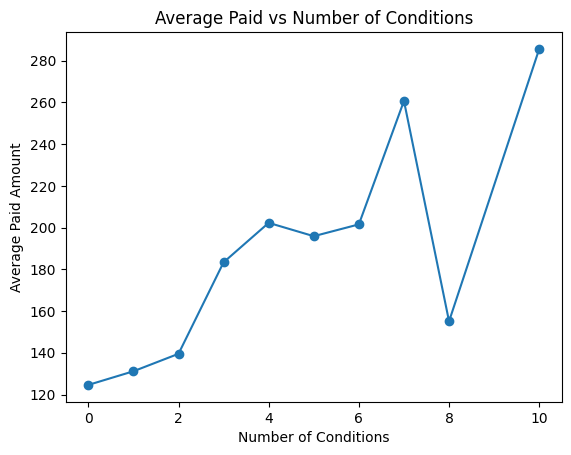

In [247]:
# Compute average paid
avg_paid = df.groupby("num_conditions")["paid_amount"].mean()

# Plot
plt.figure()
plt.plot(avg_paid.index, avg_paid.values, marker='o')

plt.xlabel("Number of Conditions")
plt.ylabel("Average Paid Amount")
plt.title("Average Paid vs Number of Conditions")

plt.show()

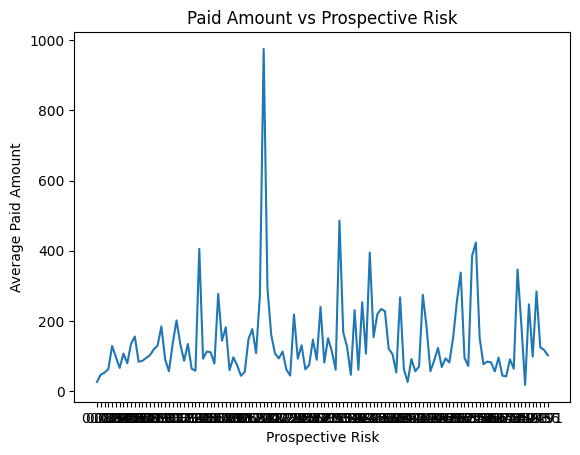

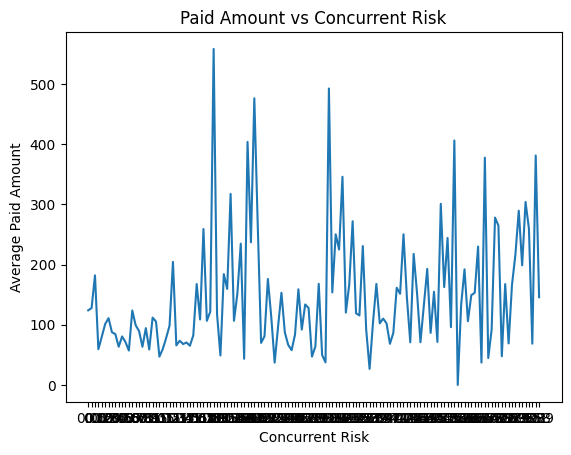

In [259]:
# Risk score compared to cost

# Group by risk scores
prospective = df.groupby("prospective_risk")["paid_amount"].mean()
concurrent = df.groupby("concurrent_risk")["paid_amount"].mean()

# Plot Prospective Risk
plt.figure()
plt.plot(prospective.index[::5], prospective.values[::5])
plt.xlabel("Prospective Risk")
plt.ylabel("Average Paid Amount")
plt.title("Paid Amount vs Prospective Risk")
plt.show()

# Plot Concurrent Risk
plt.figure()
plt.plot(concurrent.index[::5], concurrent.values[::5])
plt.xlabel("Concurrent Risk")
plt.ylabel("Average Paid Amount")
plt.title("Paid Amount vs Concurrent Risk")
plt.show()

In [261]:
# Most expensive places

df.groupby("place_of_service_description")["paid_amount"].mean().sort_values(ascending=False)

place_of_service_description
ambulatory surgical center                            844.744981
inpatient hospital                                    837.920100
skilled nursing facility                              505.049094
ambulance - land                                      466.070637
end-stage renal disease treatment facility            353.933898
outpatient hospital                                   198.506163
nursing facility                                      147.848798
residential substance abuse treatment facility        129.012596
emergency room - hospital                             127.120848
telehealth                                            121.069222
psychiatric facility-partial hospitalization          117.945011
inpatient psychiatric facility                        103.360477
independent laboratory                                 92.854328
home                                                   86.731366
urgent care facility                                   85.545

In [263]:
# Physical illness or injury cost compared to mental illness cost

mental = [
    "adhd", "depression", "eating_disorders"
]

physical = [
    "asthma", "blood_disorders", "cancer", "chronic_pain",
    "congestive_heart_failure", "chronic_respiratory_failure",
    "diabetes", "esrd", "hiv/aids",
    "hyperlipidemia", "hypertension", "lower_back_pain"
]

results = []

for group_name, cols in [("mental", mental), ("physical", physical)]:
    subset = df[df[cols].sum(axis=1) > 0]
    
    avg_paid = subset["paid_amount"].mean()
    
    results.append({
        "group": group_name,
        "avg_paid": avg_paid,
        "count": len(subset)
    })

pd.DataFrame(results)

,group,avg_paid,count
0,mental,148.270279,39169
1,physical,164.613027,103315


In [264]:
mental_only = df[(df[mental].sum(axis=1) > 0) & (df[physical].sum(axis=1) == 0)]
physical_only = df[(df[physical].sum(axis=1) > 0) & (df[mental].sum(axis=1) == 0)]

print("Mental only:", mental_only["paid_amount"].mean())
print("Physical only:", physical_only["paid_amount"].mean())

Mental only: 124.5870519620944
Physical only: 169.33205915727666


In [276]:
features = [
    "age", "adhd", "asthma", "blood_disorders", "cancer", "chronic_pain",
    "congestive_heart_failure", "chronic_respiratory_failure",
    "depression", "diabetes", "esrd", "eating_disorders", "hiv/aids",
    "hyperlipidemia", "hypertension", "lower_back_pain"
]

# Prospective risk drivers
prospective_corr = df[features + ["prospective_risk"]].corr()["prospective_risk"].drop("prospective_risk").sort_values(ascending=False)
print(prospective_corr)

# Concurrent risk drivers
concurrent_corr = df[features + ["concurrent_risk"]].corr()["concurrent_risk"].drop("concurrent_risk").sort_values(ascending=False)
print(concurrent_corr)

# Combined risk drivers
(concurrent_corr + prospective_corr).sort_values(ascending=False)

esrd                           0.667164
blood_disorders                0.422888
cancer                         0.389639
chronic_respiratory_failure    0.342076
congestive_heart_failure       0.298378
hypertension                   0.261042
diabetes                       0.256778
hyperlipidemia                 0.175879
age                            0.161554
eating_disorders               0.039012
chronic_pain                   0.030194
asthma                         0.025457
hiv/aids                       0.004316
depression                     0.001639
lower_back_pain               -0.024024
adhd                          -0.034569
Name: prospective_risk, dtype: float64
esrd                           0.571669
chronic_respiratory_failure    0.456781
blood_disorders                0.412820
congestive_heart_failure       0.371891
cancer                         0.367418
diabetes                       0.277671
hypertension                   0.275443
hyperlipidemia                 0.177461
a

esrd                           1.238833
blood_disorders                0.835708
chronic_respiratory_failure    0.798857
cancer                         0.757057
congestive_heart_failure       0.670268
hypertension                   0.536485
diabetes                       0.534449
hyperlipidemia                 0.353340
age                            0.323247
chronic_pain                   0.100909
eating_disorders               0.078669
asthma                         0.050246
depression                     0.007800
hiv/aids                       0.005387
lower_back_pain               -0.036900
adhd                          -0.078704
dtype: float64

### Summary of what I have gathered:

- There aren't any patients who are outliers in cost, no one patient is dramatically increasing costs
- Cancer treatment is typically the most expensive service, however in a real example without isolating illnesses people end up paying the most money when they have chronic respiratory failure or congestive heart failure
- Mental illnesses tend to be less costly then physical illness or injuries
- L2 and H1 Specialities are considerably more expensive than other Specialities. While NB is by far the cheapest
- Typically as a patient ages their paid amount increases, with younger groups seeing around $130 averages, and older patients seeing around $200 averages
- The amount of conditions is seen to increase the cost as well
- There seems to be not a large correlation between the paid amount and concurrent or prospective risk
- ESRD seems to have the largest effect on increasing the risk of a patient
- ADHD seems to have the lowest effect on increasing the risk of a patient